# End-to-End E-Commerce Customer Analytics & Retention Strategy
**Author:** Moh. Yusril Lukman Hakim  
**Tools:** Python (Pandas, DuckDB, Matplotlib, Seaborn)  
**Dataset:** https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci?resource=download


---

### Executive Overview
This project delivers a comprehensive end-to-end analytics pipeline designed to evaluate transactional health, profile customer behavior, and drive retention strategies through three core analytical pillars:

1. **Analytical Pillar 1: Executive Overview & Business KPI Trends** (Revenue Performance, AOV Trends, & Geographic Market Shares)
2. **Analytical Pillar 2: RFM Customer Segmentation** (Behavioral Classification across 10 Distinct Segments)
3. **Analytical Pillar 3: Advanced Cohort Retention, Top Products, & Historical CLV** (Cohort Matrix Analysis, Segment-Level Top Sellers, & Lifetime Value Projections)

## Setup Library & Environment Configuration

In [42]:
import warnings
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 100

print("Libraries successfully loaded!")

Libraries successfully loaded!


## Data Ingestion & Preprocessing Pipeline
In this step, raw transaction data is loaded, cleaned, and transformed:
- Filter missing `Customer ID`s and drop cancelled transactions (`Quantity > 0`).
- Create financial metric `TotalSales = Quantity * UnitPrice`.
- Compute individual Recency, Frequency, and Monetary (RFM) scores using 5-bin quantiles.

In [43]:
dataset_path = '/home/stradivarius/Ecommerce II.csv'
df_raw = pd.read_csv(dataset_path)

df_raw.columns = df_raw.columns.str.strip()

if 'Price' in df_raw.columns and 'UnitPrice' not in df_raw.columns:
    df_raw = df_raw.rename(columns={'Price': 'UnitPrice'})

if 'Customer ID' not in df_raw.columns and 'CustomerID' in df_raw.columns:
    df_raw = df_raw.rename(columns={'CustomerID': 'Customer ID'})

df_clean = df_raw.dropna(subset=['Customer ID']).copy()
df_clean['Customer ID'] = df_clean['Customer ID'].astype(str).str.replace('.0', '', regex=False)
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['TotalSales'] = df_clean['Quantity'] * df_clean['UnitPrice']

max_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

df_rfm = df_clean.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (max_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalSales', 'sum')
).reset_index()

df_rfm['R_Score'] = pd.qcut(df_rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])
df_rfm['F_Score'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
df_rfm['M_Score'] = pd.qcut(df_rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

df_rfm['R_Score'] = df_rfm['R_Score'].astype(int)
df_rfm['F_Score'] = df_rfm['F_Score'].astype(int)
df_rfm['M_Score'] = df_rfm['M_Score'].astype(int)

print(f"Data processed successfully! Cleaned transactions: {len(df_clean):,}, Unique customers: {len(df_rfm):,}")
display(df_clean.head(3))

Data processed successfully! Cleaned transactions: 805,298, Unique customers: 5,877


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country,TotalSales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0


## Pillar 1 Header & Key Business Questions

## Pillar 1.1: Executive Overview & Business KPI Trends

### Objective
Establish macro-level visibility into transactional performance by evaluating overall revenue, order counts, customer volume, monthly revenue trajectories, Average Order Value (AOV) seasonality, and geographic revenue concentration using DuckDB SQL queries.

In [44]:
kpi_query = """
SELECT 
    SUM(TotalSales) AS Total_Revenue,
    COUNT(DISTINCT Invoice) AS Total_Orders,
    COUNT(DISTINCT "Customer ID") AS Total_Customers,
    SUM(TotalSales) / COUNT(DISTINCT Invoice) AS Overall_AOV
FROM df_clean
"""

df_kpi = duckdb.query(kpi_query).df()

df_kpi_formatted = pd.DataFrame({
    'Metric': ['Total Revenue ($)', 'Total Orders', 'Active Customers', 'Average Order Value ($)'],
    'Value': [
        f"${df_kpi['Total_Revenue'].iloc[0]:,.2f}",
        f"{df_kpi['Total_Orders'].iloc[0]:,}",
        f"{df_kpi['Total_Customers'].iloc[0]:,}",
        f"${df_kpi['Overall_AOV'].iloc[0]:,.2f}"
    ]
})

print("High-Level Executive KPIs Summary:")
display(df_kpi_formatted)

High-Level Executive KPIs Summary:


,Metric,Value
0,Total Revenue ($),"$17,733,008.09"
1,Total Orders,"36,968"
2,Active Customers,"5,877"
3,Average Order Value ($),$479.69


### Pillar 1.2: Monthly Revenue & AOV Trends (Visualization)

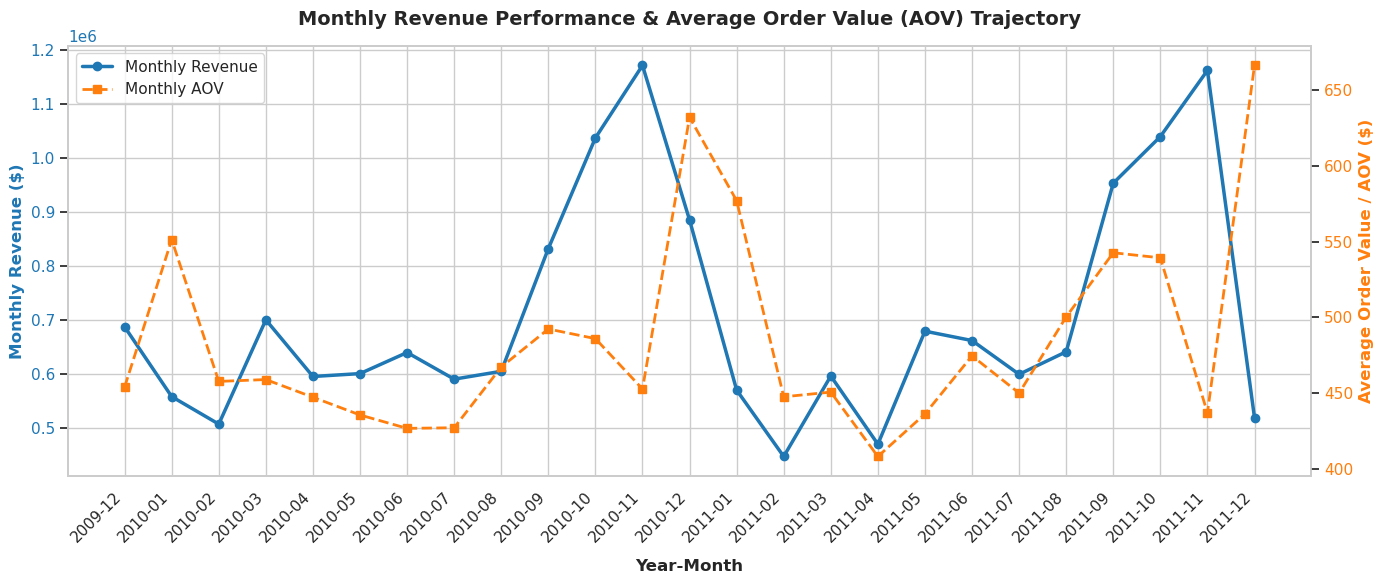

In [45]:
monthly_query = """
SELECT 
    STRFTIME(InvoiceDate, '%Y-%m') AS YearMonth,
    SUM(TotalSales) AS Monthly_Revenue,
    COUNT(DISTINCT Invoice) AS Monthly_Orders,
    SUM(TotalSales) / COUNT(DISTINCT Invoice) AS Monthly_AOV
FROM df_clean
GROUP BY 1
ORDER BY 1
"""

df_monthly = duckdb.query(monthly_query).df()

fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = '#1f77b4'
ax1.set_xlabel('Year-Month', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('Monthly Revenue ($)', color=color1, fontsize=12, fontweight='bold')
line1 = ax1.plot(df_monthly['YearMonth'], df_monthly['Monthly_Revenue'], color=color1, marker='o', linewidth=2.5, label='Monthly Revenue')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticklabels(df_monthly['YearMonth'], rotation=45, ha='right')

ax2 = ax1.twinx()  
color2 = '#ff7f0e'
ax2.set_ylabel('Average Order Value / AOV ($)', color=color2, fontsize=12, fontweight='bold')
line2 = ax2.plot(df_monthly['YearMonth'], df_monthly['Monthly_AOV'], color=color2, marker='s', linestyle='--', linewidth=2, label='Monthly AOV')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.grid(False) 

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True)

plt.title('Monthly Revenue Performance & Average Order Value (AOV) Trajectory', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Pillar 1.3: Geographic Market Performance (UK vs. Non-UK)

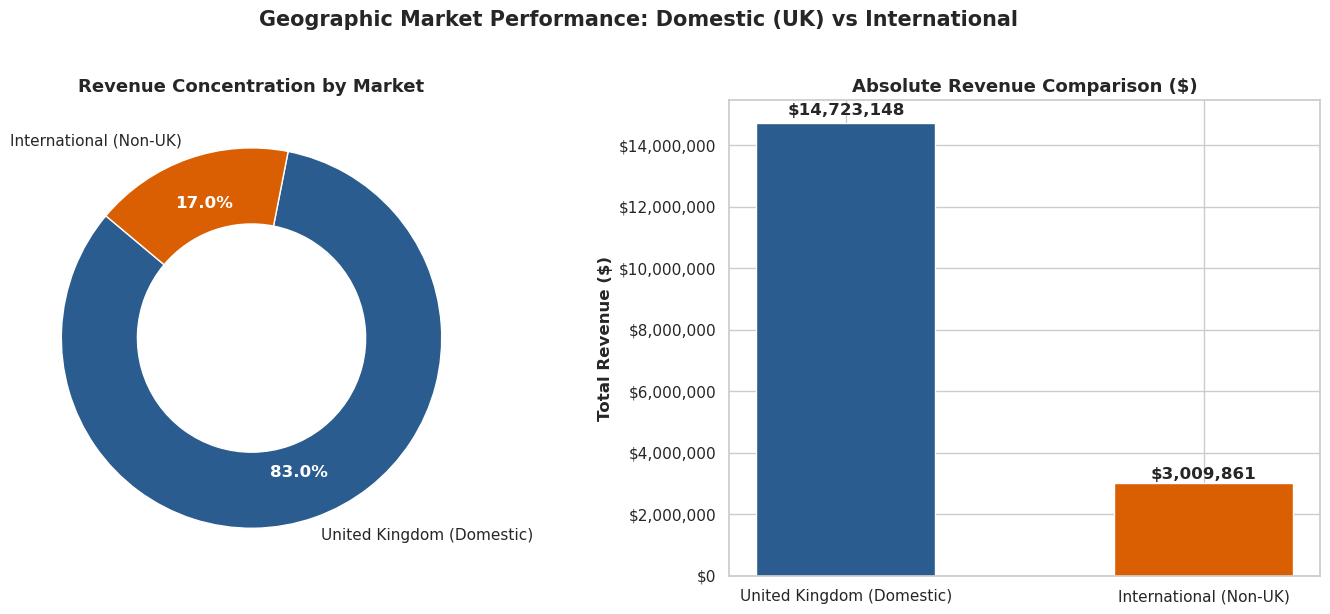

In [46]:
geo_query = """
SELECT 
    CASE WHEN Country = 'United Kingdom' THEN 'United Kingdom (Domestic)' ELSE 'International (Non-UK)' END AS Market_Region,
    SUM(TotalSales) AS Total_Revenue,
    COUNT(DISTINCT Invoice) AS Total_Orders,
    COUNT(DISTINCT "Customer ID") AS Total_Customers
FROM df_clean
GROUP BY 1
ORDER BY Total_Revenue DESC
"""

df_geo = duckdb.query(geo_query).df()
df_geo['Revenue_Share'] = (df_geo['Total_Revenue'] / df_geo['Total_Revenue'].sum()) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#2b5c8f', '#d95f02']
wedges, texts, autotexts = ax1.pie(
    df_geo['Revenue_Share'], 
    labels=df_geo['Market_Region'], 
    autopct='%1.1f%%',
    pctdistance=0.75,
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='w')
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')
ax1.set_title('Revenue Concentration by Market', fontsize=13, fontweight='bold')

bars = ax2.bar(df_geo['Market_Region'], df_geo['Total_Revenue'], color=colors, width=0.5)
ax2.set_ylabel('Total Revenue ($)', fontsize=12, fontweight='bold')
ax2.set_title('Absolute Revenue Comparison ($)', fontsize=13, fontweight='bold')
ax2.yaxis.set_major_formatter('${x:,.0f}')

for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.01), f"${yval:,.0f}", ha='center', va='bottom', fontweight='bold')

plt.suptitle('Geographic Market Performance: Domestic (UK) vs International', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Analytical Pillar 2: RFM Customer Segmentation

### Objective
Classify the active customer base into 10 distinct behavioral segments by combining their Recency, Frequency, and Monetary (RFM) scores (scale 1–5). This enables granular targeted marketing, customer retention profiling, and revenue concentration analysis.

### Pillar 2.1: Segment Mapping & Summary Generation

In [47]:
import squarify 

def assign_rfm_segment(df):
    r = df['R_Score']
    f = df['F_Score']
    m = df['M_Score']
    
    if (r >= 4) and (f >= 4) and (m >= 4):
        return 'Champions'
    elif (r >= 3) and (f >= 3) and (m >= 3):
        return 'Loyal Customers'
    elif (r >= 4) and (f <= 2):
        return 'New Customers'
    elif (r >= 3) and (f >= 2) and (m >= 2):
        return 'Potential Loyalists'
    elif (r == 3) and (f <= 2):
        return 'Promising'
    elif (r == 3) and (f == 3):
        return 'Need Attention'
    elif (r == 2) and (f >= 2) and (m >= 2):
        return 'About To Sleep'
    elif (r <= 2) and (f >= 3) and (m >= 3):
        return 'At Risk'
    elif (r == 1) and (f == 5) and (m == 5):
        return 'Can\'t Lose Them'
    elif (r <= 2) and (f <= 2):
        return 'Hibernating'
    else:
        return 'Others'

df_rfm['Segment'] = df_rfm.apply(assign_rfm_segment, axis=1)

segment_summary_query = """
SELECT 
    Segment,
    COUNT("Customer ID") AS Total_Customers,
    ROUND(COUNT("Customer ID") * 100.0 / (SELECT COUNT(*) FROM df_rfm), 2) AS Customer_Share_Pct,
    SUM(Monetary) AS Total_Revenue,
    ROUND(SUM(Monetary) * 100.0 / (SELECT SUM(Monetary) FROM df_rfm), 2) AS Revenue_Share_Pct,
    ROUND(AVG(Recency),0) AS Avg_Recency_Days,
    ROUND(AVG(Frequency),1) AS Avg_Frequency_Orders,
    ROUND(AVG(Monetary),2) AS Avg_Monetary_Spend
FROM df_rfm
GROUP BY Segment
ORDER BY Total_Revenue DESC
"""

df_segment_summary = duckdb.query(segment_summary_query).df()

print("RFM Segment Executive Summary:")
display(df_segment_summary)

RFM Segment Executive Summary:


,Segment,Total_Customers,Customer_Share_Pct,Total_Revenue,Revenue_Share_Pct,Avg_Recency_Days,Avg_Frequency_Orders,Avg_Monetary_Spend
0,Champions,1300,22.12,1.212812e+07,68.39,20.0,17.1,9329.32
1,Loyal Customers,1134,19.30,2.599641e+06,14.66,73.0,5.9,2292.45
2,About To Sleep,748,12.73,1.326713e+06,7.48,307.0,4.3,1773.68
3,Hibernating,1316,22.39,5.180772e+05,2.92,483.0,1.2,393.68
4,At Risk,192,3.27,4.231882e+05,2.39,488.0,5.1,2204.11
5,New Customers,444,7.55,3.946386e+05,2.23,28.0,1.5,888.83
6,Potential Loyalists,355,6.04,2.137485e+05,1.21,80.0,2.7,602.11
7,Promising,243,4.13,8.651549e+04,0.49,107.0,1.1,356.03
8,Others,129,2.19,3.904239e+04,0.22,369.0,2.9,302.65
9,Need Attention,16,0.27,3.328760e+03,0.02,144.0,2.7,208.05


### Pillar 2.2: Visualizing RFM Segment Distribution & Revenue Share

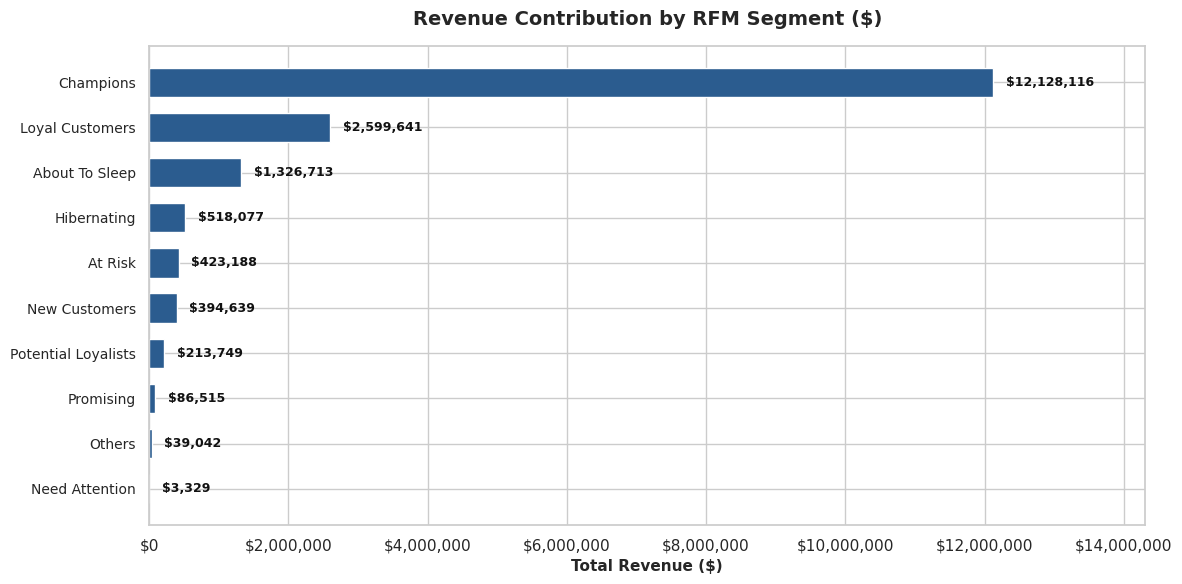

In [48]:
plt.figure(figsize=(12, 6))

df_viz_seg = df_segment_summary.sort_values(by='Total_Revenue', ascending=True)

bars = plt.barh(df_viz_seg['Segment'], df_viz_seg['Total_Revenue'], color='#2b5c8f', height=0.65)
plt.xlabel('Total Revenue ($)', fontsize=11, fontweight='bold')
plt.title('Revenue Contribution by RFM Segment ($)', fontsize=14, fontweight='bold', pad=15)
plt.gca().xaxis.set_major_formatter('${x:,.0f}')
plt.gca().tick_params(axis='y', labelsize=10)

max_rev = df_viz_seg['Total_Revenue'].max()
for bar in bars:
    xval = bar.get_width()
    plt.text(
        xval + (max_rev * 0.015), 
        bar.get_y() + bar.get_height()/2, 
        f"${xval:,.0f}", 
        ha='left', 
        va='center', 
        fontsize=9, 
        fontweight='bold', 
        color='#111111'
    )

plt.xlim(0, max_rev * 1.18)
plt.tight_layout()
plt.show()

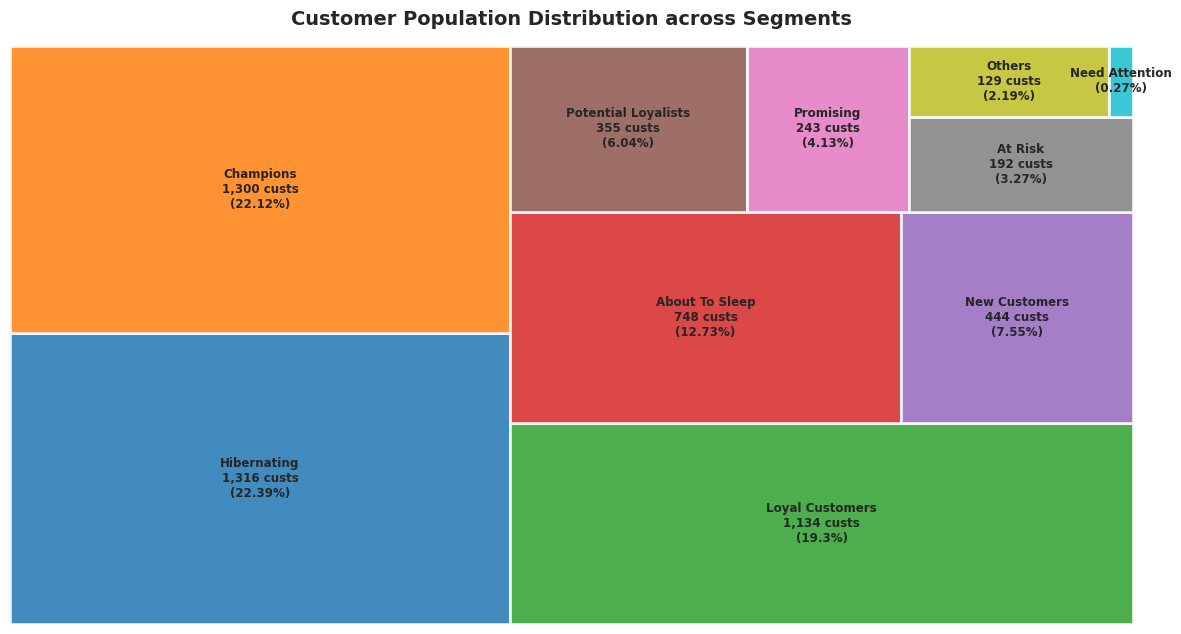

In [49]:
import squarify

plt.figure(figsize=(12, 6.5))

df_treemap = df_segment_summary.sort_values(by='Total_Customers', ascending=False)
sizes = df_treemap['Total_Customers']
colors = sns.color_palette("tab10", len(sizes))

labels = []
for _, row in df_treemap.iterrows():
    pct = row['Customer_Share_Pct']
    if pct < 1.5:
        labels.append(f"{row['Segment']}\n({pct}%)")
    else:
        labels.append(f"{row['Segment']}\n{row['Total_Customers']:,} custs\n({pct}%)")

squarify.plot(
    sizes=sizes, 
    label=labels, 
    color=colors, 
    alpha=0.85, 
    text_kwargs={'fontsize': 8.5, 'fontweight': 'bold'}, 
    bar_kwargs={'edgecolor': 'w', 'linewidth': 2}
)

plt.title('Customer Population Distribution across Segments', fontsize=14, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

## Analytical Pillar 3: Advanced Cohort Retention, Top Products & Historical CLV

### Objective
Unlock strategic customer insights across three key areas:
1. **Cohort Retention Analysis:** Tracking monthly retention rates across customer acquisition cohorts using DuckDB.
2. **Top Products per Segment:** Identifying top revenue-generating products within primary RFM customer segments.
3. **Historical CLV Analysis:** Computing mean and median Customer Lifetime Value across behavioral segments.

### Pillar 3.1 Cohort Retention Analysis (DuckDB & Heatmap)

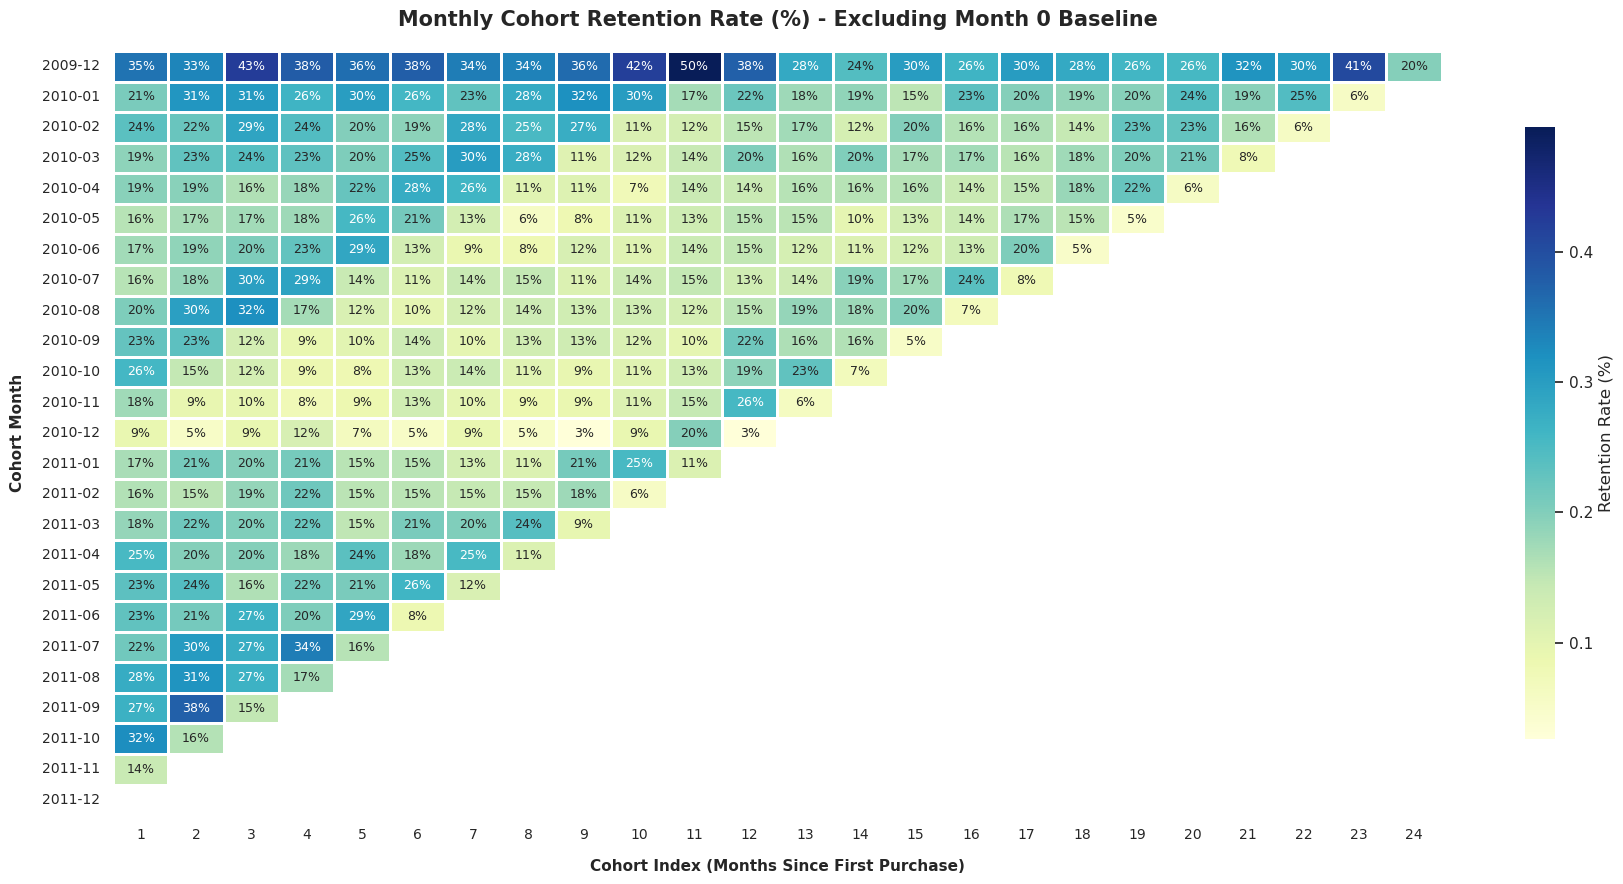

In [50]:
df_cohort['CohortMonth_Format'] = pd.to_datetime(df_cohort['CohortMonth']).dt.strftime('%Y-%m')

cohort_matrix = df_cohort.pivot(index='CohortMonth_Format', columns='CohortIndex', values='Total_Customers')
cohort_sizes = cohort_matrix.iloc[:, 0]
retention_matrix = cohort_matrix.divide(cohort_sizes, axis=0)

retention_matrix_no_zero = retention_matrix.drop(columns=[0])

fig, ax = plt.subplots(figsize=(18, 9))

ax.grid(False)

sns.heatmap(
    retention_matrix_no_zero, 
    annot=True, 
    fmt='.0%', 
    cmap='YlGnBu', 
    cbar_kws={'label': 'Retention Rate (%)', 'shrink': 0.8},
    linewidths=0.8,
    linecolor='white',
    annot_kws={'fontsize': 9, 'fontweight': 'medium'},
    ax=ax
)

plt.title('Monthly Cohort Retention Rate (%) - Excluding Month 0 Baseline', fontsize=15, fontweight='bold', pad=18)
plt.xlabel('Cohort Index (Months Since First Purchase)', fontsize=11, fontweight='bold', labelpad=12)
plt.ylabel('Cohort Month', fontsize=11, fontweight='bold', labelpad=12)
plt.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

### Pillar 3.2 Top Products per Primary RFM Segment

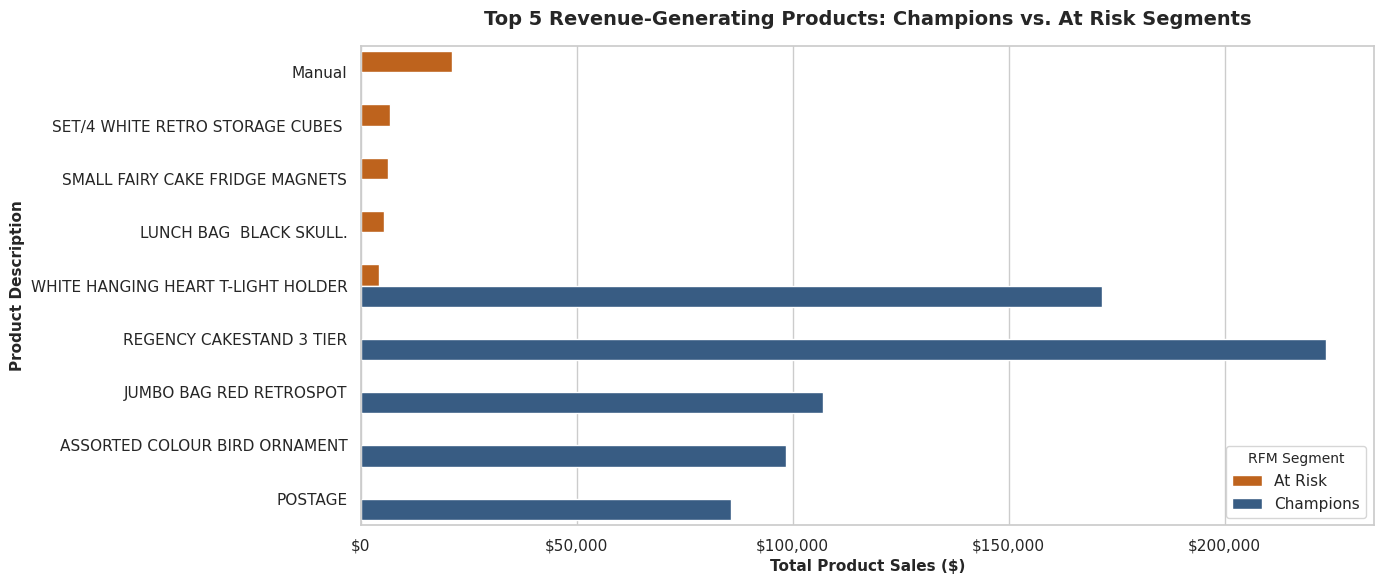

In [51]:
top_products_query = """
WITH customer_seg AS (
    SELECT "Customer ID", Segment 
    FROM df_rfm
    WHERE Segment IN ('Champions', 'At Risk')
)
SELECT 
    cs.Segment,
    c.Description AS Product_Name,
    SUM(c.TotalSales) AS Total_Product_Revenue
FROM df_clean c
JOIN customer_seg cs ON c."Customer ID" = cs."Customer ID"
WHERE c.Description IS NOT NULL
GROUP BY cs.Segment, c.Description
QUALIFY ROW_NUMBER() OVER (PARTITION BY cs.Segment ORDER BY SUM(c.TotalSales) DESC) <= 5
ORDER BY cs.Segment, Total_Product_Revenue DESC
"""

df_top_products = duckdb.query(top_products_query).df()

plt.figure(figsize=(14, 6))
sns.barplot(
    data=df_top_products, 
    x='Total_Product_Revenue', 
    y='Product_Name', 
    hue='Segment',
    palette={'Champions': '#2b5c8f', 'At Risk': '#d95f02'}
)

plt.title('Top 5 Revenue-Generating Products: Champions vs. At Risk Segments', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Product Sales ($)', fontsize=11, fontweight='bold')
plt.ylabel('Product Description', fontsize=11, fontweight='bold')
plt.gca().xaxis.set_major_formatter('${x:,.0f}')
plt.legend(title='RFM Segment', title_fontsize='10', loc='lower right')
plt.tight_layout()
plt.show()

### Pillar 3.3 Historical Customer Lifetime Value (CLV)

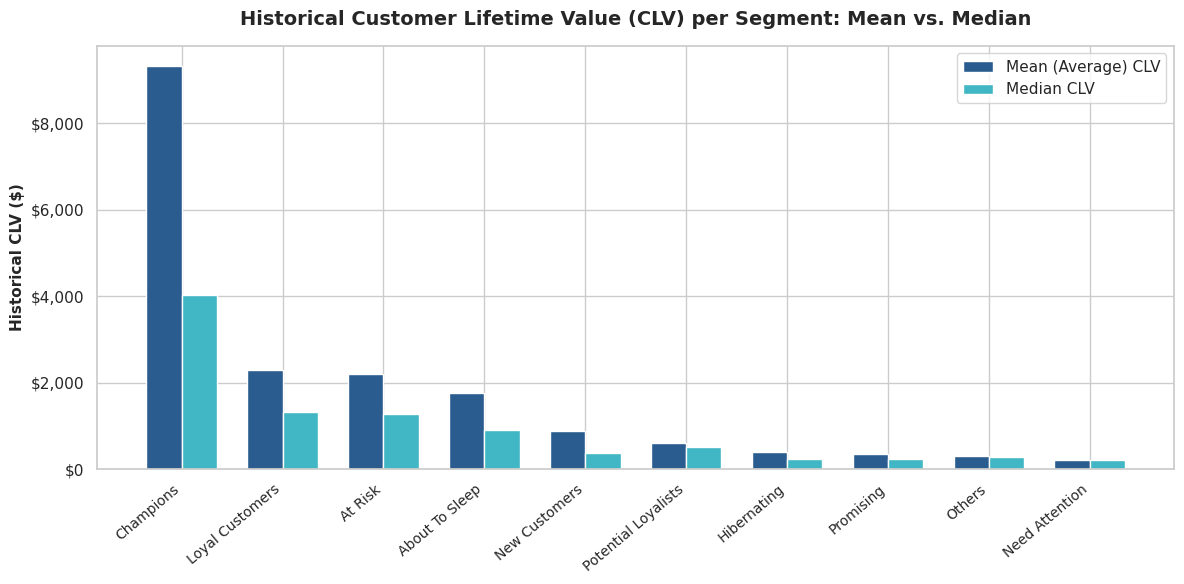

In [52]:
clv_query = """
SELECT 
    Segment,
    COUNT("Customer ID") AS Total_Customers,
    AVG(Monetary) AS Mean_CLV,
    MEDIAN(Monetary) AS Median_CLV,
    MAX(Monetary) AS Max_CLV
FROM df_rfm
GROUP BY Segment
ORDER BY Mean_CLV DESC
"""

df_clv = duckdb.query(clv_query).df()

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_clv['Segment']))
width = 0.35

rects1 = ax.bar(x - width/2, df_clv['Mean_CLV'], width, label='Mean (Average) CLV', color='#2b5c8f')
rects2 = ax.bar(x + width/2, df_clv['Median_CLV'], width, label='Median CLV', color='#41b6c4')

ax.set_ylabel('Historical CLV ($)', fontsize=11, fontweight='bold')
ax.set_title('Historical Customer Lifetime Value (CLV) per Segment: Mean vs. Median', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(df_clv['Segment'], rotation=40, ha='right', fontsize=10)
ax.yaxis.set_major_formatter('${x:,.0f}')
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

## Analytical Pillar 3 Key Findings
1. **Retention Decay:** Retention rates experience a sharp decline following Month 1, stabilizing at baseline levels in subsequent months. This emphasizes the critical importance of early onboarding campaigns (Days 1–30).
2. **Product Preference Divergence:** High-value *Champions* exhibit strong affinity towards specific top-performing SKUs compared to *At Risk* customers, presenting clear upselling opportunities.
3. **CLV Skewness:** Mean CLV is significantly higher than Median CLV across top segments, indicating that a small fraction of power-buyers drives overall segment monetary metrics.

## Multi-Sheet Data Export Pipeline

### Objective
Export all analytical findings and processed datasets into a single, multi-sheet Microsoft Excel workbook (`ecommerce_customer_analytics_export.xlsx`) for business stakeholders and reporting dashboards.

In [53]:
export_filename = 'ecommerce_customer_analytics_export.xlsx'

with pd.ExcelWriter(export_filename, engine='openpyxl') as writer:
    
    df_kpi_formatted.to_excel(writer, sheet_name='Executive_KPIs', index=False)
    
    df_monthly.to_excel(writer, sheet_name='Monthly_Trends', index=False)
    
    df_geo.to_excel(writer, sheet_name='Geographic_Performance', index=False)
    
    df_segment_summary.to_excel(writer, sheet_name='RFM_Segment_Summary', index=False)
    
    retention_matrix.to_excel(writer, sheet_name='Cohort_Retention_Matrix')
    
    df_clv.to_excel(writer, sheet_name='Historical_CLV_Summary', index=False)

print(f"Excel export completed successfully! File saved as: {export_filename}")

Excel export completed successfully! File saved as: ecommerce_customer_analytics_export.xlsx


---

## Executive Summary & Strategic Action Plan

### Strategic Takeaways & Actionable Recommendations
1. **Optimize Onboarding Strategy (Days 1–30):** With customer retention dropping significantly after Month 1, targeted welcome sequences and first-time buyer discount incentives should be introduced to improve cohort longevity.
2. **Targeted Churn Prevention:** Customers in the *At Risk* segment represent a prime opportunity for re-engagement via personalized product recommendation emails based on top-selling SKUs identified in Pillar 3.
3. **VIP Loyalty Program for Champions:** Given that the *Champions* segment generates the majority of overall revenue, implementing an exclusive VIP tier or early-access loyalty program is essential to protect core revenue streams.